In [1]:
import os
import torch
from gsplat import rasterization
import matplotlib.pyplot as plt
import sys
sys.path.append('../..')  # Adjust the path as necessary to locate the gsplat root directory
from mine.loader import initialize_model_from_ply_file
from examples.datasets.blender_nerf_synthetic import Parser, Dataset

%matplotlib inline
plt.rcParams['figure.figsize'] = (15.0, 12.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# for auto-reloading extenrnal modules
%load_ext autoreload
%autoreload 2

device = torch.device("cuda:0")

from dev_refraction.refraction_transform import *



Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
# Choose dataset by flag or name
dataset_flag = "river2"  # Change this flag to "river1" or "river2" as needed

if dataset_flag == "river1":
    wo_refraction_dataset_path = os.path.abspath("../../../../dataset/river1/refraction")
    with_refraction_dataset_path = os.path.abspath("../../../../dataset/river1/wo_refraction")
    non_refraction_model_path = os.path.abspath("../../results/favo/river_wo-refraction/ply/point_cloud_29999.ply")
elif dataset_flag == "river2":
    wo_refraction_dataset_path = os.path.abspath("../../../../dataset/river2/wo_refraction")
    with_refraction_dataset_path = os.path.abspath("../../../../dataset/river2/refraction")
    non_refraction_model_path = os.path.abspath("../../results/river2/2025-0411_13-31_refraction_GT/ply/point_cloud_29999.ply")
else:
    raise ValueError(f"Unknown dataset flag: {dataset_flag}")

# Load the dataset
parser_ref = Parser(
    data_dir=wo_refraction_dataset_path,
)
dataset_ref = Dataset(
    parser_ref,
    split="train",
)

dataloader_ref = torch.utils.data.DataLoader(
    dataset_ref,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
    pin_memory=True,
)

Loading 3D point cloud from: /home/taiki/dataset/river2/wo_refraction/points3d.ply
[Parser] Loaded 100 images from /home/taiki/dataset/river2/wo_refraction.


In [3]:
data = dataloader_ref.dataset[30]

# extract data
camtoworlds = data["camtoworld"].view(1,4,4).to(device)  # [1, 4, 4] 
# camtoworlds[:, 0, 3] *= -1 # 鉛直下向きではこれでうまくレンダリングできる
print(f"camtoworlds :\n", camtoworlds)
worldtocam = camtoworlds.inverse()
print(f"worldtocam :\n", worldtocam)
cam_center = camtoworlds[0, :3, 3].detach().clone()
Ks = data["K"].view(1,3,3).to(device)  # [1, 3, 3]
pixels = data["image"].unsqueeze(0).to(device) / 255.0  # [1, H, W, 3]
image_ids = data["image_id"]
height, width = pixels.shape[1:3]

image_name = "train", f"{image_ids:04d}" + ".png"
print(image_name)


camtoworlds :
 tensor([[[ 1.0000, -0.0000, -0.0000, -2.8008],
         [ 0.0000, -1.0000, -0.0000,  5.6017],
         [ 0.0000, -0.0000, -1.0000, 20.0000],
         [ 0.0000,  0.0000,  0.0000,  1.0000]]], device='cuda:0')
worldtocam :
 tensor([[[ 1.0000,  0.0000,  0.0000,  2.8008],
         [ 0.0000, -1.0000,  0.0000,  5.6017],
         [ 0.0000,  0.0000, -1.0000, 20.0000],
         [ 0.0000,  0.0000,  0.0000,  1.0000]]], device='cuda:0')
('train', '0030.png')


In [4]:
# get Gaussian model from ply file
gs_model_gt = initialize_model_from_ply_file(non_refraction_model_path, device=device)
# get each parameters as tensor from Gaussian model  torch.from_numpy
means     = gs_model_gt.gaussians["means"]      # shape: [N, 3]
scales    = gs_model_gt.gaussians["scales"]     # shape: [N, 3]
quats     = gs_model_gt.gaussians["rotations"]  # shape: [N, 4]
opacities = gs_model_gt.gaussians["opacities"].squeeze(-1)   # shape: (N,)
colors    = gs_model_gt.gaussians["shs"]        # shape: [N, 16, 3]


In [5]:
# Setting Refraction Parameters
n = 1.33
plane = 0.0
num_newton_iters = 10
newton_atol = 1e-6

RT = RefractionTransform(
    means=means,
    quats=quats,
    cam_center=cam_center,
    n=n,
    plane=plane,
    num_newton_iters=num_newton_iters,
    newton_atol=newton_atol,
)

trandformed_means = RT.transform_to_appearance()
dra_dr = RT.dra_dr()
dra_dz = RT.dra_dz()
dza_dr = RT.dza_dr()
dza_dz = RT.dza_dz()
jacobian = RT.dPa_dP()

In [6]:
# 補正前の Gaussian を用いてレンダリング
rgb_wo_refraction, _, _ = rasterization(
    means,
    quats,
    scales,
    opacities,
    colors,
    worldtocam,  # Notice! Render world to cam matrix 
    Ks,
    width,
    height,
    sh_degree=0,
    rasterize_mode="antialiased"
)
rgb_wo_refraction = rgb_wo_refraction.squeeze().cpu().detach().numpy()


In [7]:
# 補正後の Gaussian を用いてレンダリング
rgb_refraction, _, _ = rasterization(
    trandformed_means,
    quats,
    scales,
    opacities,
    colors,
    worldtocam,
    Ks,
    width,
    height,
    sh_degree=0,
    rasterize_mode="antialiased"
)
rgb_refraction = rgb_refraction.squeeze().cpu().detach().numpy()


GT image without refraction: /home/taiki/dataset/river2/wo_refraction/train/0030.png
GT image with refraction: /home/taiki/dataset/river2/refraction/train/0030.png


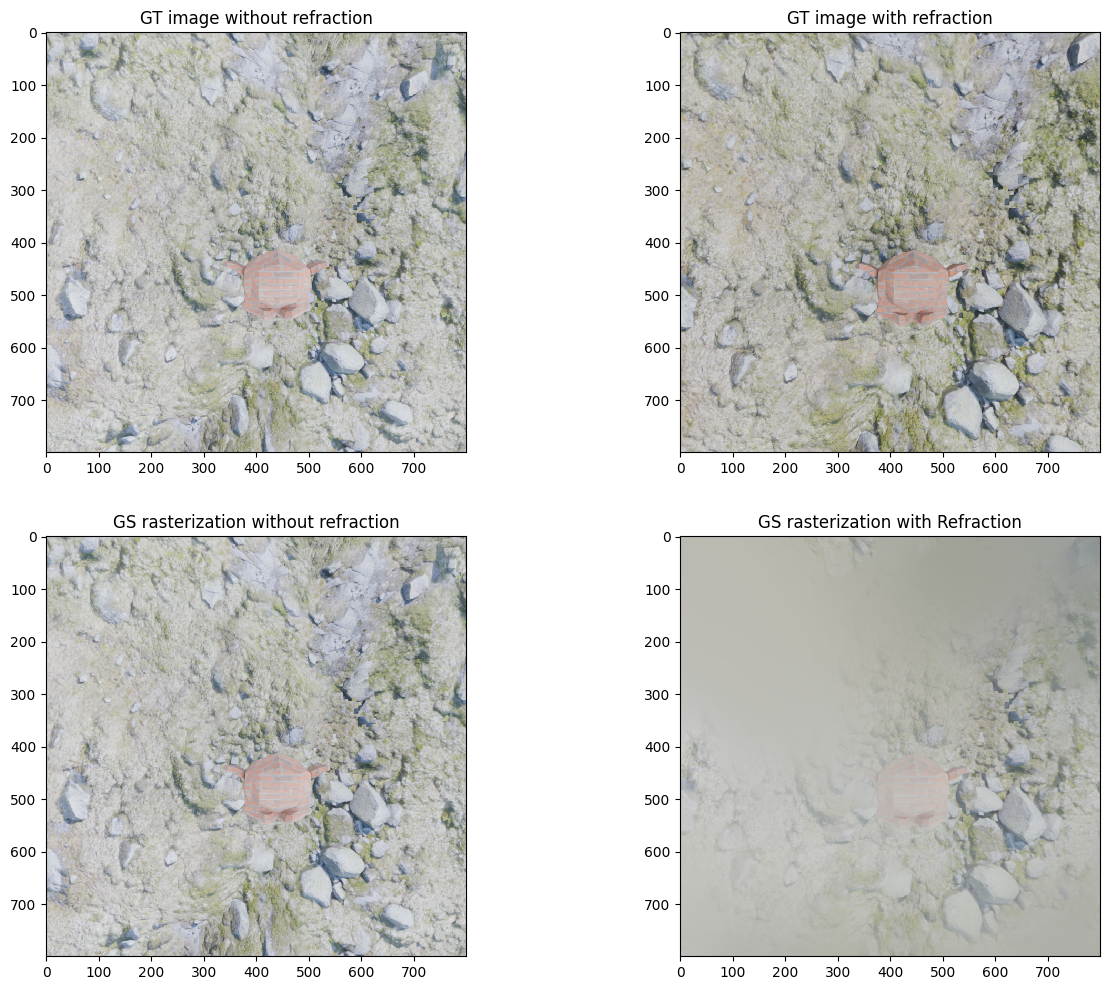

In [8]:
# Display
gt_image_path_wo_ref = os.path.join(wo_refraction_dataset_path, "train", f"{image_ids:04d}" + ".png")
gt_image_wo_ref = plt.imread(gt_image_path_wo_ref)
print(f"GT image without refraction: {gt_image_path_wo_ref}")

gt_image_path_with_ref = os.path.join(with_refraction_dataset_path, "train", f"{image_ids:04d}" + ".png")
gt_image_with_ref = plt.imread(gt_image_path_with_ref)
print(f"GT image with refraction: {gt_image_path_with_ref}")

fig, ax = plt.subplots(2, 2)
ax[0, 0].imshow(gt_image_wo_ref)
ax[0, 0].set_title("GT image without refraction")
ax[0, 1].imshow(gt_image_with_ref)
ax[0, 1].set_title("GT image with refraction")
ax[1, 0].imshow(rgb_wo_refraction)
ax[1, 0].set_title("GS rasterization without refraction")
ax[1, 1].imshow(rgb_refraction)
ax[1, 1].set_title("GS rasterization with Refraction")
plt.show()

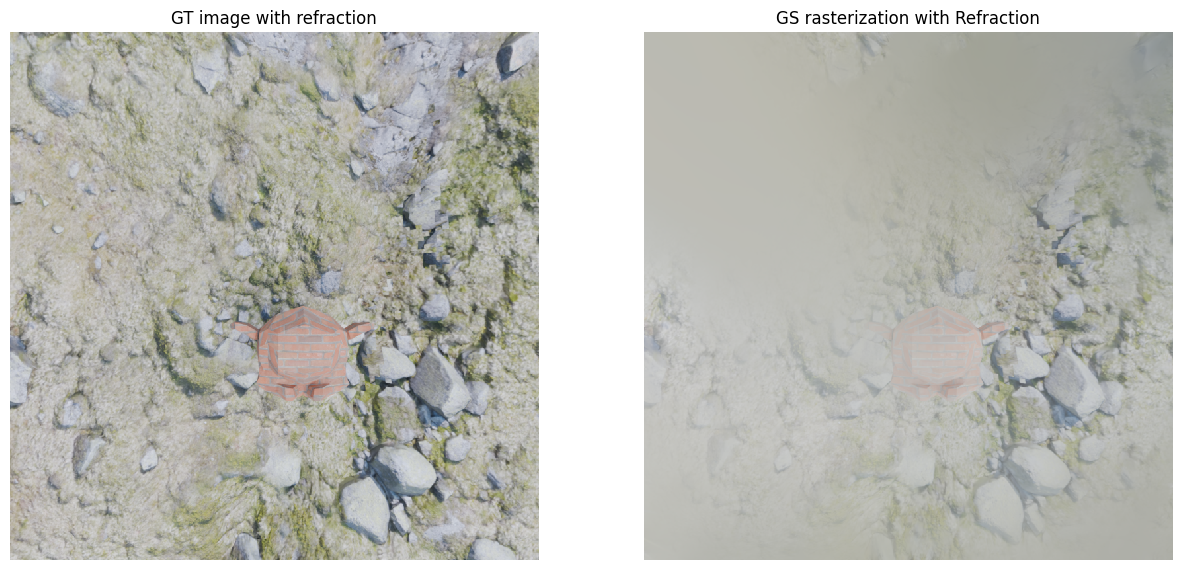

In [9]:
fig, ax = plt.subplots(1, 2)
# no axis
ax[0].axis("off")
ax[0].imshow(gt_image_with_ref)
ax[0].set_title("GT image with refraction")
ax[1].axis("off")
ax[1].imshow(rgb_refraction)
ax[1].set_title("GS rasterization with Refraction")

plt.show()

# 数値計算 VS 理論計算

In [10]:
# Output inner values
print("RT inner values:")
for key, value in vars(RT).items():
    print(f"{key}: {value}")

RT inner values:
device: cuda:0
n: 1.3300000429153442
plane: 0.0
delta: 0.01
num_newton_iters: 10
newton_atol: 1e-06
means: Parameter containing:
tensor([[  27.2438,    7.3921,  -12.6533],
        [ -34.4693,   28.5537,  -10.7403],
        [  34.6381,  -15.1602,  -11.8338],
        ...,
        [ -47.9028,   12.3228,   -8.9918],
        [  94.5975,  -18.5589, -132.0107],
        [  26.0653,  -31.4012,  -15.1913]], device='cuda:0',
       requires_grad=True)
quats: Parameter containing:
tensor([[ 0.5051,  0.1964,  0.7018,  0.4624],
        [ 0.5440, -0.0125, -0.0680,  0.8362],
        [-0.0551,  0.9312, -0.2759, -0.2316],
        ...,
        [ 0.5076,  0.6891,  0.2769,  0.4368],
        [ 0.9193, -0.0196,  0.3531,  0.1727],
        [ 0.4461,  0.5249,  0.4012,  0.6037]], device='cuda:0',
       requires_grad=True)
num_g: 999999
cam_center: tensor([-2.8008,  5.6017, 20.0000], device='cuda:0')
x0: -2.800830125808716
y0: 5.601660251617432
H: 20.0
x: tensor([ 30.0446, -31.6685,  37.4389,  .

In [11]:
# output all camera to world matrices from parser   
for i in range(len(parser_ref.camtoworlds)):
    print(f"camtoworlds_original[{i}]: \n{parser_ref.camtoworlds[i]}\n")



camtoworlds_original[0]: 
[[  1.         -0.         -0.        -11.2033205]
 [  0.         -1.         -0.        -11.2033205]
 [  0.         -0.         -1.         20.       ]
 [  0.          0.          0.          1.       ]]

camtoworlds_original[1]: 
[[  1.         -0.         -0.        -11.2033205]
 [  0.         -1.         -0.         -8.402491 ]
 [  0.         -0.         -1.         20.       ]
 [  0.          0.          0.          1.       ]]

camtoworlds_original[2]: 
[[  1.         -0.         -0.        -11.2033205]
 [  0.         -1.         -0.         -5.6016603]
 [  0.         -0.         -1.         20.       ]
 [  0.          0.          0.          1.       ]]

camtoworlds_original[3]: 
[[  1.         -0.         -0.        -11.2033205]
 [  0.         -1.         -0.         -2.8008301]
 [  0.         -0.         -1.         20.       ]
 [  0.          0.          0.          1.       ]]

camtoworlds_original[4]: 
[[  1.         -0.         -0.        -11.2033